# EPL Match Outcome Prediction Pipeline

This notebook demonstrates a pipeline for predicting English Premier League (EPL) match outcomes. It trains models on data from seasons 2020-2023 and tests their performance on the 2024 season. The optimization goal is overall accuracy, aiming for approximately 68%.

## 0. Install Libraries

In [2]:
#!pip install scikit-learn xgboost pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

## 1. Load Data

In [3]:
DATA_PATH = "matches.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

## 2. ELO Rating System (Clean Single-Pass)

This section implements a simple ELO rating system to quantify team strength over time. ELO ratings are updated after each match to reflect the outcome and adjust future predictions.

In [4]:
def expected_score(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

def update_elo(ra, rb, score_a, k=32):
    """score_a: 1=win, 0.5=draw, 0=loss for team A"""
    ea = expected_score(ra, rb)
    new_ra = ra + k * (score_a - ea)
    new_rb = ra + k * ((1 - score_a) - (1 - ea))
    return new_ra, new_rb

In [5]:
def build_elo_column(df):
    """
    Computes ELO in a single chronological pass.
    Avoids double updating by triggering only on the 'Home' match record.
    """
    elo_store = {}
    team_elo_col, opp_elo_col = [], []
    updated = set()

    for idx, row in df.iterrows():
        t, opp, venue = row["team"], row["opponent"], row["venue"]

        t_elo   = elo_store.get(t,   1500.0)
        opp_elo = elo_store.get(opp, 1500.0)

        team_elo_col.append(t_elo)
        opp_elo_col.append(opp_elo)

        if venue == "Home":
            match_key = (str(row["date"]), t, opp)
            if match_key not in updated:
                updated.add(match_key)
                score = 1.0 if row["result"] == "W" else (0.5 if row["result"] == "D" else 0.0)
                new_h, new_a = update_elo(t_elo, opp_elo, score)
                elo_store[t] = new_h
                elo_store[opp] = new_a

    return pd.Series(team_elo_col, index=df.index), pd.Series(opp_elo_col, index=df.index)

df["team_elo"], df["opp_elo"] = build_elo_column(df)
df["elo_diff"] = df["team_elo"] - df["opp_elo"]

## 3. Rolling Form Features

This section calculates rolling averages of various match statistics to capture recent team performance, often referred to as 'form'.

In [6]:
def rolling_feature(df, col, window=5):
    return (
        df.groupby("team")[col]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

df["form_pts"] = df.groupby("team")["result"].transform(
    lambda x: x.shift(1).map({"W": 3, "D": 1, "L": 0}).rolling(5, min_periods=1).mean()
)

cols_to_roll = ["gf", "ga", "xg", "xga", "sot", "poss"]
for c in cols_to_roll:
    df[f"team_{c}_avg"] = rolling_feature(df, c, window=5)

## 4. Encode Categorical Features

Categorical features like 'venue' and team names need to be converted into numerical representations for machine learning models.

In [7]:
df["is_home"]  = (df["venue"] == "Home").astype(int)

name_map = {
    "Brighton":         "Brighton and Hove Albion",
    "Manchester Utd":   "Manchester United",
    "Newcastle Utd":    "Newcastle United",
    "Nott'ham Forest":  "Nottingham Forest",
    "Sheffield Utd":    "Sheffield United",
    "Tottenham":        "Tottenham Hotspur",
    "West Brom":        "West Bromwich Albion",
    "West Ham":         "West Ham United",
    "Wolves":           "Wolverhampton Wanderers",
}
df["opponent_clean"] = df["opponent"].replace(name_map)

all_teams = sorted(set(df["team"].unique()) | set(df["opponent_clean"].unique()))
le_team = LabelEncoder()
le_team.fit(all_teams)

df["team_enc"] = le_team.transform(df["team"])
df["opp_enc"]  = df["opponent_clean"].apply(
    lambda x: le_team.transform([x])[0] if x in le_team.classes_ else -1
)

le_result = LabelEncoder()
df["result_enc"] = le_result.fit_transform(df["result"])  # D=0, L=1, W=2

## 5. Define Features & Split Data

This section defines the features and target variable for the models and then splits the data into training and testing sets based on seasons.

In [8]:
FEATURES = [
    "is_home", "team_elo", "opp_elo", "elo_diff", "form_pts",
    "team_gf_avg", "team_ga_avg", "team_xg_avg", "team_xga_avg",
    "team_sot_avg", "team_poss_avg", "team_enc", "opp_enc",
]

TARGET = "result_enc"

df_clean = df.dropna(subset=FEATURES).copy()

TRAIN_SEASONS = [2020, 2021, 2022, 2023]
TEST_SEASON   = [2024]

train = df_clean[df_clean["season"].isin(TRAIN_SEASONS)]
test  = df_clean[df_clean["season"].isin(TEST_SEASON)]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train size : {len(X_train)} rows  (seasons {TRAIN_SEASONS})")
print(f"Test size  : {len(X_test)}  rows  (season  {TEST_SEASON})\n")

Train size : 3245 rows  (seasons [2020, 2021, 2022, 2023])
Test size  : 1517  rows  (season  [2024])



In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 6. Train & Evaluate Models

This section defines and trains various machine learning models, then evaluates their performance, focusing on overall accuracy.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, eval_metric="mlogloss", random_state=42),
}

results_summary = {}

In [11]:
for name, model in models.items():
    xtr = X_train_scaled if name == "Logistic Regression" else X_train
    xte = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(xtr, y_train)
    preds = model.predict(xte)

    acc = accuracy_score(y_test, preds)
    results_summary[name] = acc

    print(f"{'─'*50}")
    print(f"  {name}  (Accuracy: {acc:.3f})")
    print(f"{'─'*50}")
    print(classification_report(y_test, preds, target_names=le_result.classes_))

──────────────────────────────────────────────────
  Logistic Regression  (Accuracy: 0.512)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           D       0.00      0.00      0.00       330
           L       0.51      0.66      0.57       592
           W       0.52      0.65      0.57       595

    accuracy                           0.51      1517
   macro avg       0.34      0.44      0.38      1517
weighted avg       0.40      0.51      0.45      1517

──────────────────────────────────────────────────
  Random Forest  (Accuracy: 0.652)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           D       0.79      0.32      0.45       330
           L       0.64      0.74      0.68       592
           W       0.64      0.75      0.69       595

    accuracy                           0.65      1517
   macro avg       0.69      0.60      0.61      1517
weighted avg 

## 7. Confusion Matrix and Model Comparison

This section visualizes the confusion matrix for the best-performing model and provides a comparison of all models' overall accuracy.

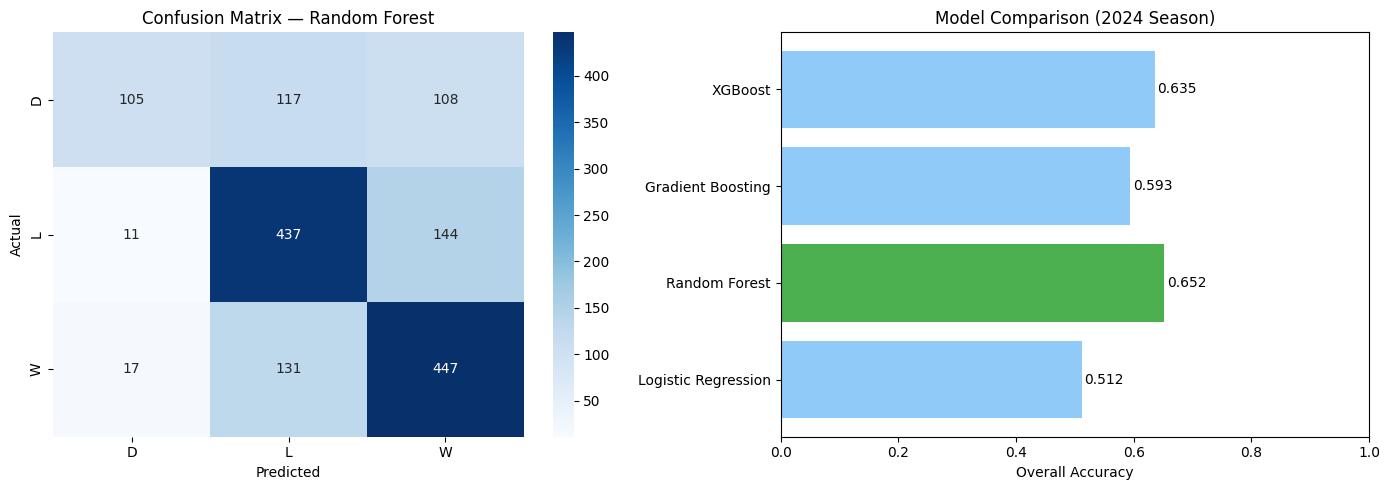


Best model: Random Forest (Accuracy=65.2%)


In [12]:
best_name = max(results_summary, key=results_summary.get)
best_model = models[best_name]

xte_best = X_test_scaled if best_name == "Logistic Regression" else X_test
best_preds = best_model.predict(xte_best)

cm = confusion_matrix(y_test, best_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_result.classes_,
            yticklabels=le_result.classes_, ax=axes[0])
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

names  = list(results_summary.keys())
scores = list(results_summary.values())
colors = ["#4CAF50" if n == best_name else "#90CAF9" for n in names]
axes[1].barh(names, scores, color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Overall Accuracy")
axes[1].set_title("Model Comparison (2024 Season)")
for i, v in enumerate(scores):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest model: {best_name} (Accuracy={results_summary[best_name]:.1%})")